# Dial network: classes that differ only in how channels interact — p90 pilot, 2026-10-07

The proof classes separate even with all coupling removed ([control](proof_strength_nuisance_261006.ipynb)), so they cannot show whether a representation reads interaction. Here every node is the same noise-driven process and only the coupling function changes; gain and node timescale vary per recording. Result: mean $|r|$ is near chance, the mean of each SPI, $m$, is organised by gain with classes mixed, and SPI–SPI $z$ is organised by class once coupling is detectable. $z$ is not blind to gain or timescale, and neither dial is recovered as a single coordinate. Exploratory pilot; settings were fixed by a strength-only scout before p90.

In [1]:
from pathlib import Path
import sys, warnings
import matplotlib.pyplot as plt, pandas as pd
ROOT = Path.cwd().resolve()
while not (ROOT / 'src').is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
warnings.filterwarnings('ignore')
from scripts import dial_network as D
rows, bank, P = D.load(); cache = {}
kw = dict(colors=D.COLORS, display=D.DISPLAY, stem='dial', cache=cache)
print(f"{len(rows)} recordings; {len(bank['spi_order'])} SPIs; M={D.M}, T={D.T}")

496 recordings; 289 SPIs; M=16, T=1000


$x_i(t)=a\,x_i(t-1)+k\,g_i\sum_j W_{ij}\,\phi_\beta\!\big(x_j(t-\tau_{ij})/\sigma_a\big)+\varepsilon_i(t)$, with $\varepsilon\sim N(0,1)$ and $\sigma_a=(1-a^2)^{-1/2}$. Inputs follow a random directed acyclic graph with at most two inputs per node, so gain cannot destabilise the system and dependence rises with it. Rows of $W$ have unit norm and $g_i\sim U[.5,1.5]$, so pairs differ in strength within a recording. $\phi_\beta$ mixes a bounded odd term $\tanh u$ and a bounded even term $e^{-u^2/2}$, each standardized and mutually uncorrelated under $N(0,1)$.

Classes are two dials crossed: coupling shape ($\beta=0$ near-linear, $\beta=1$ even) and lag structure ($\tau=1$; $\tau=5$; $\tau\sim U\{1..9\}$ per edge), plus an uncoupled class; 40 recordings each. Per recording, independently of class: gain $k$ log-uniform on $[.25,1.2]$, node coefficient $a\sim U[.3,.7]$, and the graph. Sweeps (24 recordings per level) vary $\beta$ at lag 1, and the spread of lags around 5 at $\beta=0$. Even coupling leaves a driver and its receiver uncorrelated, but two receivers of one driver still correlate, so mean $|r|$ is not zero for those classes. Features and label-free fits as in the proof notebook.

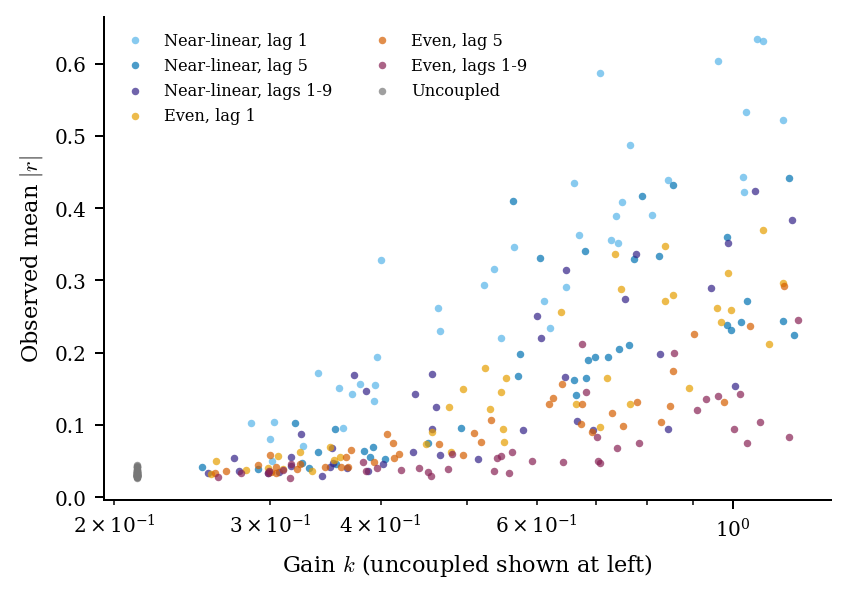

In [2]:
fig = D.design_figure(rows, P); plt.show()

Six classes and the uncoupled reference, one fit per representation. Top: colour is class. Bottom: the same points coloured by gain.

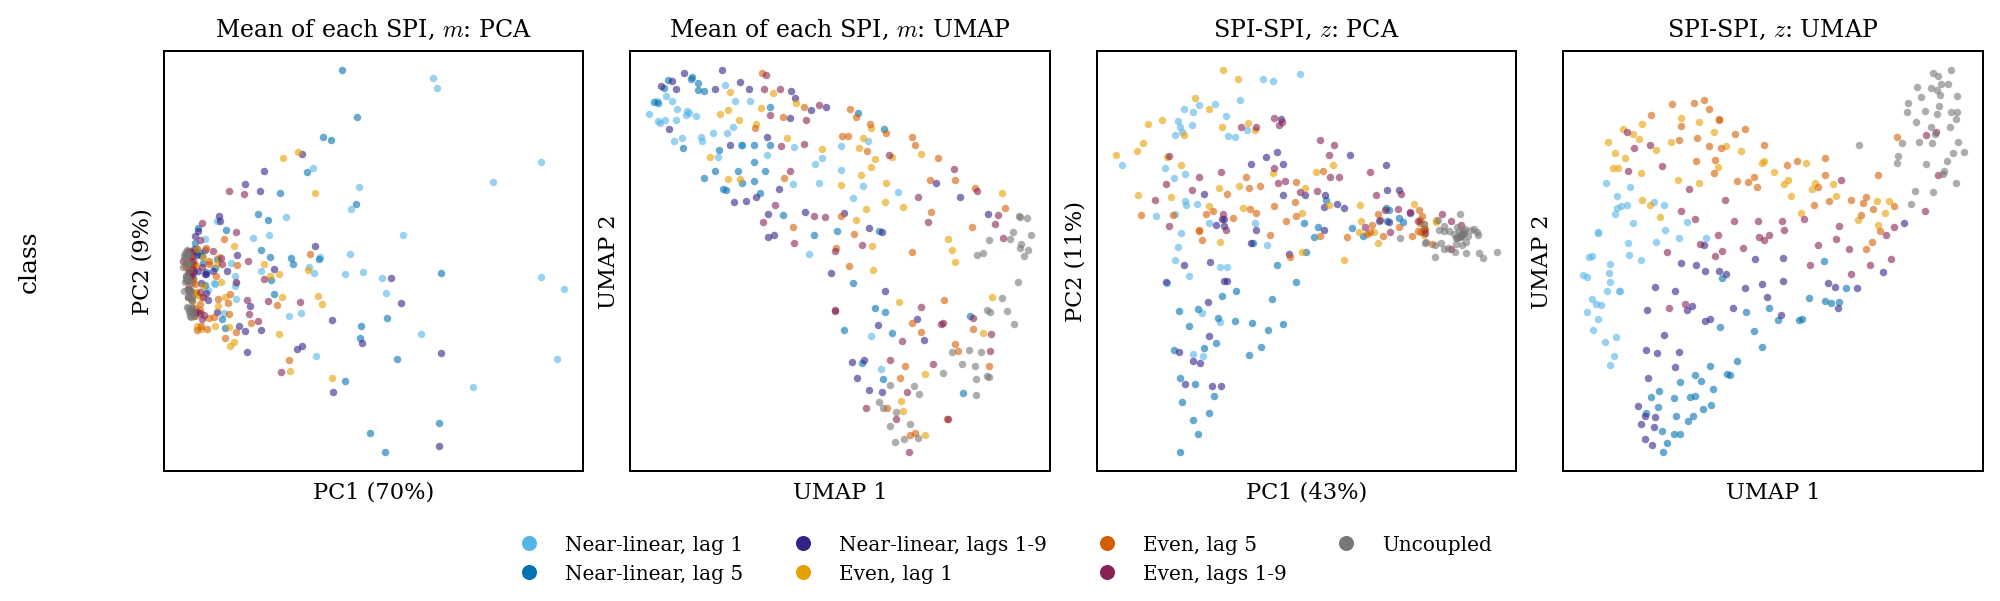

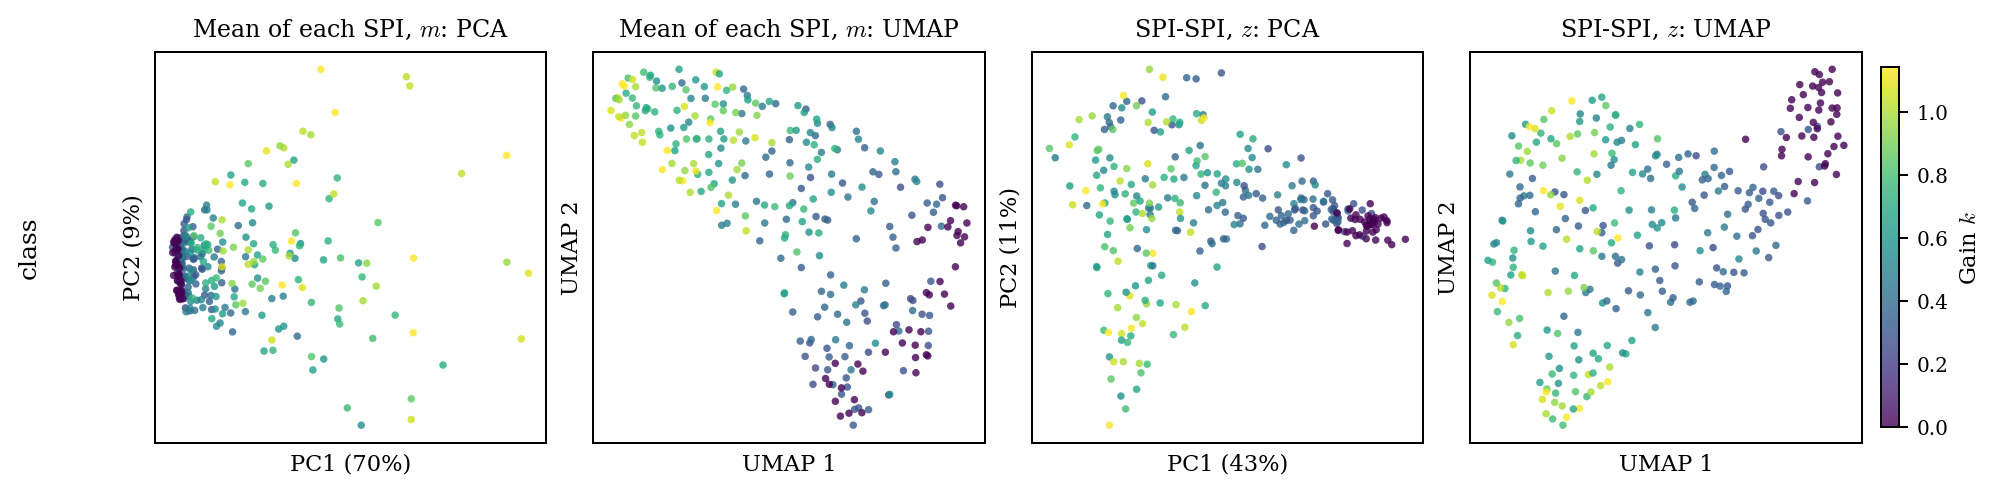

In [3]:
fig = P.embedding_figure(rows, bank, D.PANEL, ('class',), D.OUT, **kw); plt.show()
fig = P.embedding_figure(rows, bank, D.PANEL, ('class',), D.OUT, color='value', value='gain', value_label='Gain $k$', **kw); plt.show()

Scores in the 50-PC space of each fit (seven labels, chance .14). `class_agreement` is the share of five nearest neighbours in the same class; `shape` and `lag` score each dial alone among coupled recordings; the three gain columns split coupled recordings into thirds. `share_*` is the fraction of variance between classes, and explained within class by gain and by $a$. `z_ordered` keeps direction (ordered pairs, no symmetrisation).

In [4]:
table = D.class_table(rows, bank, P); table.to_csv(D.OUT / 'class-table.csv'); table.T

representation,mean |r|,mean,z,z_ordered
silhouette,-0.20,-0.12,0.07,0.07
class_agreement,0.24,0.46,0.73,0.75
shape_agreement,0.51,0.72,0.88,0.89
lag_agreement,0.33,0.57,0.79,0.80
class_agreement_low_gain,0.11,0.28,0.53,0.56
class_agreement_mid_gain,0.20,0.47,0.76,0.79
class_agreement_high_gain,0.26,0.62,0.85,0.85
ceiling,0.34,0.66,0.84,0.86
share_class,0.35,0.27,0.27,0.28
share_gain,0.48,0.46,0.36,0.36


Dose-response. If a dial can be read off, some coordinate should follow it rather than the gain. Rows are the leading label-free components and one SPI pair per dial named before any outcome was read; entries are $|\rho|$ with the dial, the gain and $a$.

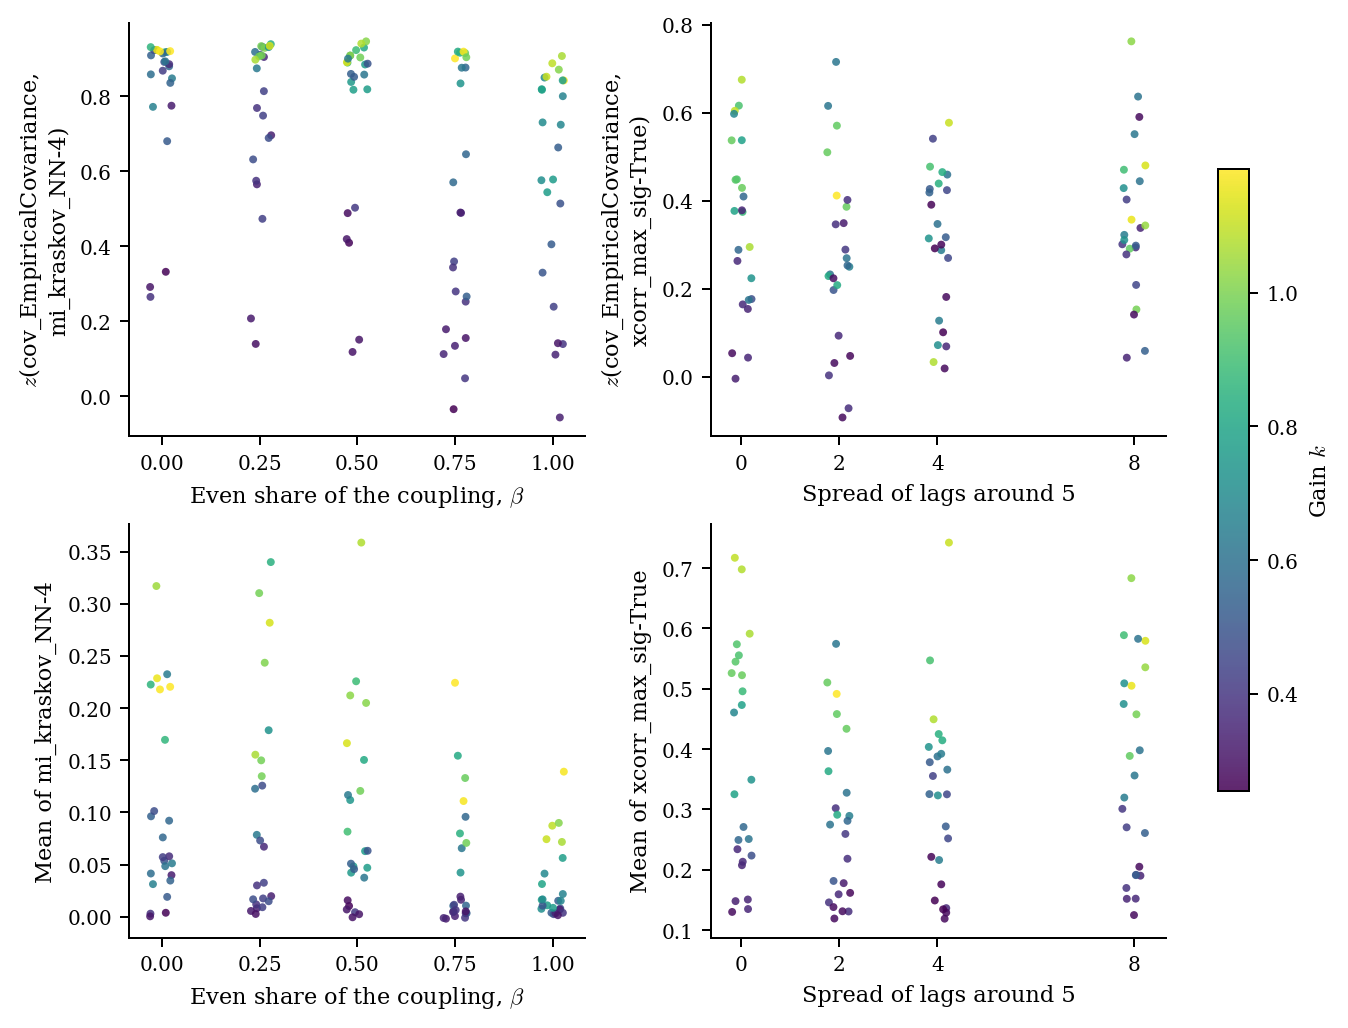

,sweep,readout,dial,gain,a
0,beta,mean |r|,0.39,0.78,0.42
1,beta,mean PC1,0.44,0.78,0.35
2,beta,mean PC2,0.03,0.22,0.88
3,beta,z PC1,0.36,0.55,0.61
4,beta,z PC2,0.06,0.53,0.23
5,beta,"z(cov_EmpiricalCovariance, mi_kraskov_NN-4)",0.39,0.75,0.39
6,beta,mean cov_EmpiricalCovariance,0.40,0.77,0.41
7,beta,mean mi_kraskov_NN-4,0.35,0.78,0.44
8,spread,mean |r|,0.04,0.84,0.48
9,spread,mean PC1,0.01,0.90,0.40


In [5]:
fig = D.sweep_figure(rows, bank, P); plt.show()
sweeps = D.sweep_table(rows, bank, P); sweeps.to_csv(D.OUT / 'sweep-table.csv', index=False); sweeps

**Reading.**

- *The baselines are much closer to noise than $z$.* Neighbour class agreement: mean $|r|$ .24, $m$ .46, $z$ .73 (chance .14); grouped logistic accuracy on ten PCs .34, .66, .84. Each dial alone: shape .72 against .88, lag structure .57 against .79. The mean embedding is a fan ordered by gain with classes interleaved; the $z$ embedding has the uncoupled recordings at one tip and classes along separate branches.
- *Both need detectable coupling.* In the weakest third of gains agreement is .28 ($m$) and .53 ($z$); in the strongest .62 and .85.
- *$z$ is not blind to the nuisances.* Gain explains 36% of $z$ variance within class and $a$ 18%, against 46% and 16% for $m$; classes take 27% of each. The difference is in how the variance is arranged: gain moves $z$ along a class's branch, and moves $m$ along a direction shared by all classes.
- *Neither dial is recovered as a coordinate.* No leading component of $m$ or $z$ follows $\beta$ or lag spread more than it follows gain. The named pair $z$(covariance, Kraskov MI) follows gain (.75) rather than $\beta$ (.39): at high gain it is near .9 for every $\beta$, because receivers of a shared driver are ranked alike by both statistics. Lag spread leaves no trace in any readout here ($|\rho|\le .19$). The questions "how nonlinear" and "how variable are the lags" are not answered by this analysis.
- *Scope.* One synthetic family, $M=16$, $T=1000$, one pilot; class structure in $z$ is diffuse (silhouette .07), so this is organisation, not clean clusters. Direction-preserving $z$ adds little (.75).

Run: `scripts/dial_network.py` (`scout`, `prepare`, external-corpus farm, `extract`); rebuilt by `scripts/build_dial_network_notebook.py`. Full p90, estimator seed 261122, 496 recordings, none failed (two reran after a job walltime).